We import the necessary libraries

In [32]:
import numpy as np
import math
import cvxpy as cp
import itertools
from collections import Counter
from itertools import product, combinations
from typing import List

import scipy.sparse as sps

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from z3 import *


# Functions

Now we introduce all the functions we will be using.

In [33]:
def DecodeMultiset(v_tuple, unique_dims): # Ex: DecodeMultiset([2, 3], [3, 4]) --> [3,3,4,4,4]
    """
    Helper to turn a tuple of multiplicities back into a readable sorted multiset tuple
    """
    multiset = []
    for idx, count in enumerate(v_tuple):
        multiset.extend([unique_dims[idx]] * count)
    return tuple(sorted(multiset))

def clean_real(val):  #Just to print cleanly the results and avoid complex things.
    """Helper to remove floating point noise for clean printing."""
    r = np.real(val)
    return 0.0 if abs(r) < 1e-10 else r

def GeneralizedKrawtchouk(j, k, n, gamma, delta):
    """
    Computes the generalized Krawtchouk polynomial: tilde{K}_j(k; n, gamma, delta)
    """
    res = 0
    for alpha in range(max(0, j - (n - k)), min(k, j) + 1):
        term = ((-1)**alpha * math.comb(n - k, j - alpha) * math.comb(k, alpha) * (gamma**((n - k) - (j - alpha))) * (delta**(j - alpha)))
        res += term
    return res

def Delta(dimensions):
        """
        Calculates the threshold D = sqrt(dim[n])
        """
        return math.sqrt(math.prod(dimensions)) 

def AME_Distance(dimensions):
    """
    Calculates the dimensional minimum distance for an AME floor(Delta)+1
    """
    return np.floor(Delta(dimensions))+1

class MixedDimensionalErrorBasis:

    def __init__(self, dimensions):
        """
        Initializes the basis for a mixed-dimensional system.
        """
        self.dimensions = dimensions
        self.n = len(dimensions)  # Number of subsystems
        self.dim_n = np.prod(dimensions)  # Total Hilbert space dimension
        self.local_bases = [self._generate_local_basis(d) for d in self.dimensions] # Pre-calculate the Weyl-Heisenberg (Pauli) basis for each subsystem

    def _generate_local_basis(self, d):
        """
        Generates the d^2 generalized Pauli operators (Shift and Clock) for a d-level system. Returns a list of sparse matrices and their identity status.
        """
        omega = np.exp(2j * np.pi / d)

        X = np.zeros((d, d), dtype=complex) 
        Z = np.zeros((d, d), dtype=complex)
        
        for k in range(d):
            X[k, (k - 1) % d] = 1.0 
            Z[k, k] = omega ** k
            
        basis = []
        for a in range(d):
            for b in range(d):

                Xa = np.linalg.matrix_power(X, a)
                Zb = np.linalg.matrix_power(Z, b)
                E = np.dot(Xa, Zb)
                
                # Flag the operator as the identity if both powers are 0
                is_identity = (a == 0 and b == 0)

                basis.append({"matrix": sps.csr_matrix(E), "is_identity": is_identity})
                
        return basis

    def iter_full_basis(self):
        """
        A generator that yields every possible tensor product of local Pauli operators and tracks the 'dimension multiset' (which subsystems have errors).
        """
        for local_ops in product(*self.local_bases):
            dim_multiset = []
            for i, op in enumerate(local_ops):
                if not op["is_identity"]:
                    dim_multiset.append(self.dimensions[i])
            
            dim_multiset = tuple(sorted(dim_multiset))
            
            E_matrix = local_ops[0]["matrix"]
            for op in local_ops[1:]:
                E_matrix = sps.kron(E_matrix, op["matrix"], format='csr') 
                
            yield E_matrix, dim_multiset

    def build_vector(self, state_dict):
        """
        Helper to convert string-based kets (e.g., '0113') into a normalized NumPy state vector.
        """
        psi = np.zeros(self.dim_n, dtype=complex)
        for ket, coeff in state_dict.items():
            clean_ket = ket.replace('|', '').replace('>', '').replace(',', '').strip()
            coords = tuple(int(char) for char in clean_ket)
            
            flat_idx = np.ravel_multi_index(coords, self.dimensions)
            psi[flat_idx] = coeff
            
        norm = np.linalg.norm(psi)
        if norm > 0:
            psi = psi / norm
            
        return psi
    
    def PartialTrace(self, rho, keep_indices):
        """
        Computes the partial trace of a dense matrix `rho`.
        keep_indices is a tuple of the subsystem indices to keep (i.e., S). The complementary subsystems (S^c) will be traced out.
        """

        keep = list(keep_indices)
        lose = [i for i in range(self.n) if i not in keep]
        
        rho_tensor = rho.reshape(tuple(self.dimensions) + tuple(self.dimensions)) #row indices + column indices
        
        axes = keep + [k + self.n for k in keep] + lose + [l + self.n for l in lose]
        rho_tensor = np.transpose(rho_tensor, axes)
        
        keep_dim = int(np.prod([self.dimensions[i] for i in keep])) if keep else 1
        lose_dim = int(np.prod([self.dimensions[i] for i in lose])) if lose else 1
        
        rho_tensor = rho_tensor.reshape((keep_dim, keep_dim, lose_dim, lose_dim))
        
        return np.trace(rho_tensor, axis1=2, axis2=3)

    # ENUMERATOR FUNCTIONS
    def ShorLaflammeEnumerator(self, M_dense, N_dense):
        """
        Calculates the Shor-Laflamme enumerators A_w and B_w for all w.
        """
        A_vals = {}
        B_vals = {}
        
        M = sps.csr_matrix(M_dense)
        N = sps.csr_matrix(N_dense)
        
        for E, v in self.iter_full_basis():
            if v not in A_vals:
                A_vals[v] = 0j
                B_vals[v] = 0j
                
            E_dagger = E.conjugate().transpose()
            
            term1 = (E @ M).diagonal().sum()
            term2 = (E_dagger @ N).diagonal().sum()
            A_vals[v] += term1 * term2
            
            EME = E @ M @ E_dagger
            term3 = (EME @ N).diagonal().sum()
            B_vals[v] += term3
            
        return A_vals, B_vals
    
    def CalligraphicEnumerator(self, M_dense, N_dense):
        """
        Calculates the calligraphic enumerators mathcal{A}'_S and mathcal{B}'_S for all S.
        """
        cal_A_vals = {}
        cal_B_vals = {}
        
        all_subsets = []
        for r in range(self.n + 1):
            for subset in combinations(range(self.n), r):
                all_subsets.append(subset)
                
        trace_cache_M = {}
        trace_cache_N = {}
        for S in all_subsets:
            trace_cache_M[S] = self.PartialTrace(M_dense, S)
            trace_cache_N[S] = self.PartialTrace(N_dense, S)
            
        for S in all_subsets:
            S_c = tuple(i for i in range(self.n) if i not in S)
            
            M_S = trace_cache_M[S]
            N_S = trace_cache_N[S]
            cal_A_vals[S] = np.trace(M_S @ N_S)
            
            M_Sc = trace_cache_M[S_c]
            N_Sc = trace_cache_N[S_c]
            cal_B_vals[S] = np.trace(M_Sc @ N_Sc)
            
        return cal_A_vals, cal_B_vals
    
    def UnitaryEnumerator(self, M_dense, N_dense):
        """
        Calculates the unitary enumerators A'_w and B'_w for all w.
        """
        Adash_vals = {}
        Bdash_vals = {}

        all_subsets = []
        for r in range(self.n + 1):
            for subset in combinations(range(self.n), r):
                all_subsets.append(subset)
                
        trace_cache_M = {}
        trace_cache_N = {}
        for S in all_subsets:
            trace_cache_M[S] = self.PartialTrace(M_dense, S)
            trace_cache_N[S] = self.PartialTrace(N_dense, S)

        for S in all_subsets:
            w = tuple(sorted([self.dimensions[i] for i in S]))
            
            S_c = tuple(i for i in range(self.n) if i not in S)
            
            if w not in Adash_vals:
                Adash_vals[w] = 0.0 + 0.0j
                Bdash_vals[w] = 0.0 + 0.0j

            # A'_w term =Tr( M_S @ N_S )
            M_S = trace_cache_M[S]
            N_S = trace_cache_N[S]
            term_A = np.trace(M_S @ N_S)
            Adash_vals[w] += term_A
            
            # B'_w = Tr( M_{S^c} @ N_{S^c} )
            M_Sc = trace_cache_M[S_c]
            N_Sc = trace_cache_N[S_c]
            term_B = np.trace(M_Sc @ N_Sc)
            Bdash_vals[w] += term_B

        return Adash_vals, Bdash_vals

    def ShadowEnumerator(self, M_dense, N_dense):
        """
        Computes the multiset Shadow enumerators S_w for all w.
        """
        S_vals = {}
        
        all_subsets = []
        for r in range(self.n + 1):
            all_subsets.extend(combinations(range(self.n), r))
            
        M_S_dict = {}
        N_S_dict = {}
        for S in all_subsets:
            M_S_dict[S] = self.PartialTrace(M_dense, S)
            N_S_dict[S] = self.PartialTrace(N_dense, S)
            
        T_by_w = {}
        for T in all_subsets:
            w = tuple(sorted([self.dimensions[i] for i in T]))
            if w not in T_by_w:
                T_by_w[w] = []
            T_by_w[w].append(T)
            
        for w, T_list in T_by_w.items():
            s_sum = 0.0 + 0.0j
            
            for T in T_list:
                T_set = set(T)
                T_c = set(range(self.n)) - T_set 
                
                for S in all_subsets:
                    S_set = set(S)
                    
                    intersect_size = len(S_set.intersection(T_c))
                    sign = (-1) ** intersect_size
                    
                    M_S = M_S_dict[S]
                    N_S = N_S_dict[S]
                    
                    tr_M_S_N_S = np.trace(M_S @ N_S)
                    s_sum += sign * tr_M_S_N_S
            
            S_vals[w] = s_sum 
            
        return S_vals
    
    # AME ENUMERATOR FUNCTIONS
    def AME_CalligraphicUnitary(self):
        """
        Computes mathcal{A}'_S(|psi>) for an AME state for all S.
        """
        results = {}
        for r in range(self.n + 1):
            for S in combinations(range(self.n), r):
                dim_S = math.prod([self.dimensions[i] for i in S]) if S else 1
                dim_Sc = self.dim_n / dim_S
                
                results[S] = 1.0 / min(dim_S, dim_Sc)
        return results

    def AME_UnitaryEnumerator(self):
        """
        Computes A'_w(|psi>) for an AME state for all w.
        """
        results = {}
        unique_dims = list(set(self.dimensions))
        total_counts = Counter(self.dimensions)
        
        w_ranges = [range(total_counts[d] + 1) for d in unique_dims]
        
        for w_counts in product(*w_ranges):
            w_tuple = DecodeMultiset(w_counts, unique_dims)
            
            dim_w = 1
            prod_binom = 1.0
            for idx, d in enumerate(unique_dims):
                c = w_counts[idx]
                dim_w *= (d ** c)
                prod_binom *= math.comb(total_counts[d], c)
                
            denominator = min(dim_w, self.dim_n / dim_w)
            results[w_tuple] = prod_binom / denominator
            
        return results

    def AME_ShorLaflamme(self):
        """
        Computes the Shor-Laflamme enumerator A_w(|psi>) for an AME state for all w.
        """
        results = {}
        unique_dims = list(set(self.dimensions))
        total_counts = Counter(self.dimensions)
        
        w_ranges = [range(total_counts[d] + 1) for d in unique_dims]
        
        for w_counts in product(*w_ranges):
            w_tuple = DecodeMultiset(w_counts, unique_dims)
            
            outer_prod = 1.0
            for idx, d in enumerate(unique_dims):
                outer_prod *= math.comb(total_counts[d], w_counts[idx])
                
            v_ranges = [range(w_counts[idx] + 1) for idx in range(len(unique_dims))]
            sum_v = 0.0
            len_w = sum(w_counts)
            
            for v_counts in product(*v_ranges):
                len_v = sum(v_counts)
                sign = (-1)**(len_w - len_v)
                
                dim_v = 1
                inner_prod = 1.0
                for idx, d in enumerate(unique_dims):
                    v_c = v_counts[idx]
                    dim_v *= (d ** v_c)
                    inner_prod *= math.comb(w_counts[idx], v_c) * (d ** v_c)
                    
                denominator = min(dim_v, self.dim_n / dim_v)
                sum_v += (sign / denominator) * inner_prod
                
            results[w_tuple] = outer_prod * sum_v
            
        return results

    def AME_Shadow(self):
        """
        Computes the Shadow enumerator S_w(|psi>) for an AME state for all w.
        """
        results = {}
        unique_dims = list(set(self.dimensions))
        total_counts = Counter(self.dimensions)
        
        w_ranges = [range(total_counts[d] + 1) for d in unique_dims]
        
        v_ranges = [range(total_counts[d] + 1) for d in unique_dims]
        all_v_counts = list(product(*v_ranges))
        
        for w_counts in product(*w_ranges):
            w_tuple = DecodeMultiset(w_counts, unique_dims)
            sum_v = 0.0
            
            for v_counts in all_v_counts:
                dim_v = 1
                inner_prod = 1.0
                
                for idx, d in enumerate(unique_dims):
                    v_c = v_counts[idx]
                    n_val = total_counts[d]
                    w_c = w_counts[idx]
                    
                    dim_v *= (d ** v_c)
                    j_val = n_val - w_c
                    
                    krawtchouk_val = GeneralizedKrawtchouk(j_val, v_c, n_val, 1, 1)
                    binom_val = math.comb(n_val, v_c)
                    
                    inner_prod *= krawtchouk_val * binom_val
                    
                denominator = min(dim_v, self.dim_n / dim_v)
                sum_v += inner_prod / denominator
                
            results[w_tuple] = sum_v
            
        return results
    
    # CHECK IF A GIVEN STATE IN DICTIONARY FORM IS AN AME BY COMPUTING THE ENUMERATORS AND THE PARTIAL TRACES
    def AME_Check(self, psi_dict):
        """
        Checks if a given state is an AME state by evaluating its enumerators printing its single-party partial traces (just helpful for the tripartite final section).
        """
     
        P = np.zeros((self.dim_n, self.dim_n), dtype=complex)

        psi = self.build_vector(psi_dict)
        P += np.outer(psi, psi.conj())

        print(f"System dimensions: {self.dimensions}")
        print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}")

        A_vals, B_vals = self.ShorLaflammeEnumerator(P, P)
        S_vals = self.ShadowEnumerator(P, P)

        sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

        print(f"\n{'Multiset v':<15} | {'A_v (def)':<12} | {'B_v (def)':<12} | {'S_v (def)':<12} ")
        print("-" * 75)

        for v in sorted_multisets:
            A_real = np.real(A_vals[v])
            B_real = np.real(B_vals[v])
            S_real = np.real(S_vals[v])
            
            print(f"{str(v):<15} | {A_real:<12.4f} | {B_real:<12.4f} | {S_real:<12.4f} ")
        
        print(f"\nChecking partial traces...")
        for i in range(self.n):
            print(f"Reduction to subsystem {self.dimensions[i]} (Index {i}):")
            print(np.round(self.PartialTrace(P, [i]), 4))
            print("-" * 30)


    #MACWILLIAMS TRANSFORM
    def DualAndShadowTransform(self, A_vals):
        """
        Converts Shor-Laflamme enumerators into Dual and Shadow enumerators using the mixed-dimensional MacWilliams identities given by Krawtchouk polynomials.
        """
        counts = Counter(self.dimensions)
        unique_dims = list(counts.keys())
        max_mults = [counts[d] for d in unique_dims]
        
        multiset_ranges = [range(m + 1) for m in max_mults]
        all_counts = list(product(*multiset_ranges))
        
        B_vals = {}
        S_vals = {}
        
        keys_cache = {counts: DecodeMultiset(counts, unique_dims) for counts in all_counts}
        
        for v_counts in all_counts:
            v_key = keys_cache[v_counts]
            b_sum = 0.0
            s_sum = 0.0
            
            for w_counts in all_counts:
                w_key = keys_cache[w_counts]
                
                A_w = A_vals.get(w_key, 0.0)
                
                if A_w == 0:
                    continue 
                
                prod_B = 1.0
                prod_S = 1.0
                w_size = sum(w_counts) 
                
                for idx, d in enumerate(unique_dims):
                    md_v = v_counts[idx]
                    md_w = w_counts[idx]
                    md_N = max_mults[idx]
                    
                    prod_B *= GeneralizedKrawtchouk(md_v, md_w, md_N, 1, d**2 - 1)
                    prod_S *= GeneralizedKrawtchouk(md_v, md_w, md_N, d - 1, d + 1)
                    
                b_sum += A_w * prod_B
                s_sum += A_w * ((-1)**w_size) * prod_S
                
            B_vals[v_key] = b_sum / self.dim_n
            S_vals[v_key] = s_sum / self.dim_n
            
        return B_vals, S_vals
    
# LINEAR PROGRAM, we go step by step introducing the constraints to detect which constrain is failing 
def LP_mixed_code(dimensions, K, D):
    """
    Tests the existence of a mixed-dimensional code using dimensional distance and the linear program.
    """
    dim_n = np.prod(dimensions)
    counts = Counter(dimensions)
    unique_dims = list(counts.keys())
    max_mults = [counts[d] for d in unique_dims]
    
    multiset_ranges = [range(m + 1) for m in max_mults]
    all_multisets = list(product(*multiset_ranges))
    num_vars = len(all_multisets)
    
    # We build the matrices giving the linear transformation from Proposition 18 in the preprint
    T_B = np.zeros((num_vars, num_vars))
    T_S = np.zeros((num_vars, num_vars))
    
    for i, v in enumerate(all_multisets):
        for j, w in enumerate(all_multisets):
            prod_B, prod_S = 1.0, 1.0
            w_size = sum(w) 
            
            for idx, d in enumerate(unique_dims):
                md_v, md_w, md_N = v[idx], w[idx], max_mults[idx]
                prod_B *= GeneralizedKrawtchouk(md_v, md_w, md_N, 1, d**2 - 1)
                prod_S *= GeneralizedKrawtchouk(md_v, md_w, md_N, d - 1, d + 1)
                
            T_B[i, j] = (1 / dim_n) * prod_B
            T_S[i, j] = (1 / dim_n) * ((-1)**w_size) * prod_S

    A = cp.Variable(num_vars, nonneg=True) #A_v>=0
    B = T_B @ A
    S = T_S @ A
    
    current_constraints = []
    
    # Base constraints (Empty set)
    for i, v in enumerate(all_multisets):
        if sum(v) == 0:
            current_constraints.extend([A[i] == K**2, K * B[i] == K**2])
            
    prob = cp.Problem(cp.Minimize(0), current_constraints)
    if prob.solve() is None or prob.status in ["infeasible", "infeasible_inaccurate"]:
        return False, "Failed immediately at trivial empty set constraints."

    # Distance equality constraints (0 < dim_weight < D)
    for i, v in enumerate(all_multisets):
        if sum(v) > 0: 
            v_set = DecodeMultiset(v, unique_dims)
            dim_weight = math.prod(v_set) 
            
            if dim_weight < D:
                current_constraints.append(A[i] == K * B[i])
                if K == 1:
                    current_constraints.append(A[i] == 0) # The pure state!
                
    prob = cp.Problem(cp.Minimize(0), current_constraints)
    if prob.solve() in ["infeasible", "infeasible_inaccurate"]:
        return False, "Failed at MacWilliams equality (A_v = K*B_v) for dim_weight < D."
    
     # Shadow Enumerator Bounds (S_v >= 0)
    for i, v in enumerate(all_multisets):
        current_constraints.append(S[i] >= 0)
        prob = cp.Problem(cp.Minimize(0), current_constraints)
        prob.solve()
        if prob.status in ["infeasible", "infeasible_inaccurate"]:
            v_set = DecodeMultiset(v, unique_dims)
            return False, f"Failed at Shadow enumerator bound S_v >= 0 for multiset {v_set}"

    # Dual MacWilliams bounds (K*B_v >= A_v for dim_weight >= D)
    for i, v in enumerate(all_multisets):
        if sum(v) > 0:
            v_set = DecodeMultiset(v, unique_dims)
            dim_weight = math.prod(v_set)
            
            if dim_weight >= D:
                current_constraints.append(K * B[i] >= A[i])
                prob = cp.Problem(cp.Minimize(0), current_constraints)
                prob.solve()
                if prob.status in ["infeasible", "infeasible_inaccurate"]:
                    return False, f"Failed at MacWilliams inequality K*B_v >= A_v for multiset {v_set} (dimwt={dim_weight})"

    
    A_sol = A.value
    B_sol = B.value
    S_sol = S.value
    

    # AI helped printing cleanly the next tables
    results_to_print = []
    
    max_multiset_len = len("Multiset v")
    
    for i, v in enumerate(all_multisets):
        v_set = DecodeMultiset(v, unique_dims)
        dim_weight = math.prod(v_set) if v_set else 1 # Empty set has dimensional weight 1
        
        a_val = round(float(A_sol[i]), 5)
        b_val = round(float(B_sol[i]), 5)
        s_val = round(float(S_sol[i]), 5)
        
        v_str = str(v_set)
        
        if len(v_str) > max_multiset_len:
            max_multiset_len = len(v_str)
        
        results_to_print.append((dim_weight, v_set, a_val, b_val, s_val, v_str))
        
    results_to_print.sort(key=lambda x: (x[0], x[1]))
    
    col_width = max_multiset_len + 1

    print("\nSUCCESS! The LP found a valid mathematical solution.")
    print(f"{'Multiset v':<{col_width}} | {'A_v':<10} | {'B_v':<10} | {'S_v':<10}")
    print("-" * (col_width + 40)) 
    
    for row in results_to_print:
        _, _, a_val, b_val, s_val, v_str = row
        print(f"{v_str:<{col_width}} | {a_val:<10.5f} | {b_val:<10.5f} | {s_val:<10.5f}")

    return True, "Code satisfies all linear constraints!"

# PURE LINEAR PROGRAM 
def pure_LP_mixed_code(dimensions, K, D):
    """
    Tests the existence of a pure mixed-dimensional code using dimensional distance and the linear program. Same function as before but imposing null coefficients below the dimensional minimum distance.
    """
    dim_n = np.prod(dimensions)
    counts = Counter(dimensions)
    unique_dims = list(counts.keys())
    max_mults = [counts[d] for d in unique_dims]
    
    multiset_ranges = [range(m + 1) for m in max_mults]
    all_multisets = list(product(*multiset_ranges))
    num_vars = len(all_multisets)
    
    T_B = np.zeros((num_vars, num_vars))
    T_S = np.zeros((num_vars, num_vars))
    
    for i, v in enumerate(all_multisets):
        for j, w in enumerate(all_multisets):
            prod_B, prod_S = 1.0, 1.0
            w_size = sum(w) 
            
            for idx, d in enumerate(unique_dims):
                md_v, md_w, md_N = v[idx], w[idx], max_mults[idx]
                prod_B *= GeneralizedKrawtchouk(md_v, md_w, md_N, 1, d**2 - 1)
                prod_S *= GeneralizedKrawtchouk(md_v, md_w, md_N, d - 1, d + 1)
                
            T_B[i, j] = (1 / dim_n) * prod_B
            T_S[i, j] = (1 / dim_n) * ((-1)**w_size) * prod_S

    A = cp.Variable(num_vars, nonneg=True) #A_v>=0
    B = T_B @ A
    S = T_S @ A
    
    current_constraints = []
    
    for i, v in enumerate(all_multisets):
        if sum(v) == 0:
            current_constraints.extend([A[i] == K**2, K * B[i] == K**2])
            
    prob = cp.Problem(cp.Minimize(0), current_constraints)
    if prob.solve() is None or prob.status in ["infeasible", "infeasible_inaccurate"]:
        return False, "Failed immediately at trivial empty set constraints."

    for i, v in enumerate(all_multisets):
        if sum(v) > 0: 
            v_set = DecodeMultiset(v, unique_dims)
            dim_weight = math.prod(v_set) 
            
            if dim_weight < D:
                current_constraints.append(A[i] == K * B[i])
                current_constraints.append(A[i] == 0) # NEW: The purity condition!!!
                
    prob = cp.Problem(cp.Minimize(0), current_constraints)
    if prob.solve() in ["infeasible", "infeasible_inaccurate"]:
        return False, "Failed at MacWilliams equality (A_v = K*B_v) for dim_weight < D."
    
    for i, v in enumerate(all_multisets):
        current_constraints.append(S[i] >= 0)
        prob = cp.Problem(cp.Minimize(0), current_constraints)
        prob.solve()
        if prob.status in ["infeasible", "infeasible_inaccurate"]:
            v_set = DecodeMultiset(v, unique_dims)
            return False, f"Failed at Shadow enumerator bound S_v >= 0 for multiset {v_set}"

    for i, v in enumerate(all_multisets):
        if sum(v) > 0:
            v_set = DecodeMultiset(v, unique_dims)
            dim_weight = math.prod(v_set)
            
            if dim_weight >= D:
                current_constraints.append(K * B[i] >= A[i])
                prob = cp.Problem(cp.Minimize(0), current_constraints)
                prob.solve()
                if prob.status in ["infeasible", "infeasible_inaccurate"]:
                    return False, f"Failed at MacWilliams inequality K*B_v >= A_v for multiset {v_set} (dimwt={dim_weight})"

    
    A_sol = A.value
    B_sol = B.value
    S_sol = S.value
    
    # AI helped printing cleanly the next tables
    
    results_to_print = []
    
    max_multiset_len = len("Multiset v")
    
    for i, v in enumerate(all_multisets):
        v_set = DecodeMultiset(v, unique_dims)
        dim_weight = math.prod(v_set) if v_set else 1 
        
        a_val = round(float(A_sol[i]), 5)
        b_val = round(float(B_sol[i]), 5)
        s_val = round(float(S_sol[i]), 5)
        
        v_str = str(v_set)
        
        if len(v_str) > max_multiset_len:
            max_multiset_len = len(v_str)
        
        results_to_print.append((dim_weight, v_set, a_val, b_val, s_val, v_str))
        
    results_to_print.sort(key=lambda x: (x[0], x[1]))
    
    col_width = max_multiset_len + 1

    print("\nSUCCESS! The LP found a valid mathematical solution.")
    print(f"{'Multiset v':<{col_width}} | {'A_v':<10} | {'B_v':<10} | {'S_v':<10}")
    print("-" * (col_width + 40)) 
    
    for row in results_to_print:
        _, _, a_val, b_val, s_val, v_str = row
        print(f"{v_str:<{col_width}} | {a_val:<10.5f} | {b_val:<10.5f} | {s_val:<10.5f}")

    return True, "Code satisfies all linear constraints!"

#TRIPARTITE AME STATES GRID SOLVER
def TripartiteAMEGrid(d1, d2, d3):
    """
    Solves the Tripartite AME grid, printing the solution and generating a dictionary with the coefficients of the AME found.
    """
    print(f"Searching for AME grid: d1={d1}, d2={d2}, d3={d3}")
    
    if d3 > d1 * d2:
        print(f"Error: d3 ({d3}) must be <= d1*d2 ({d1 * d2}). No solution possible.\n")
        return None

    solver = Solver()

    # W is the grid of probabilities (a_ij)
    W = [[Real(f'W_{i}_{j}') for j in range(d2)] for i in range(d1)]
    # B is the boolean assignment to partition k
    B = [[[Bool(f'B_{i}_{j}_{k}') for k in range(d3)] for j in range(d2)] for i in range(d1)]

    # Constraints
    for i in range(d1):
        for j in range(d2):
            solver.add(W[i][j] >= 0)
            # Each cell belongs to exactly 1 partition
            solver.add(Sum([If(B[i][j][k], 1, 0) for k in range(d3)]) == 1)

    for i in range(d1):
        solver.add(Sum([W[i][j] for j in range(d2)]) == 1 / RealVal(d1))

    for j in range(d2):
        solver.add(Sum([W[i][j] for i in range(d1)]) == 1 / RealVal(d2))

    for k in range(d3):
        partition_weight = Sum([If(B[i][j][k], W[i][j], 0) for i in range(d1) for j in range(d2)])
        solver.add(partition_weight == 1 / RealVal(d3))

    for k in range(d3):
        for i in range(d1):
            solver.add(Sum([If(B[i][j][k], 1, 0) for j in range(d2)]) <= 1)
        for j in range(d2):
            solver.add(Sum([If(B[i][j][k], 1, 0) for i in range(d1)]) <= 1)
            
    if solver.check() == sat:
        model = solver.model()

        # Again, AI prints this beautifully
        print("Solution Found!\n")
        
        psi_dict = {}
        
        print("=== Grid ===")
        for i in range(d1):
            row_str = []
            for j in range(d2):
                w_val = model.evaluate(W[i][j]).as_fraction()
                w_float = float(w_val.numerator) / float(w_val.denominator)
                
                assigned_k = None
                for k in range(d3):
                    if is_true(model.evaluate(B[i][j][k])):
                        assigned_k = k
                        break
                
                if w_float > 0:
                    cell_str = f"{w_val.numerator}/{w_val.denominator}|{assigned_k}>"
                    ket = f"{i}{j}{assigned_k}"
                    psi_dict[ket] = math.sqrt(w_float)
                else:
                    cell_str = "0"
                    
                row_str.append(cell_str.rjust(10))
            print(" | ".join(row_str))
        
        return psi_dict
    else:
        print("UNSATISFIABLE: No such grid exists under these constraints.\n")
        return None

# Examples of code enumerators

## $[[3,1,2]]_3$

In [34]:
dimensions = [3, 3, 3] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)

code_basis_defs = [
    {'000': 1, '111': 1, '222': 1}, # Vector 1
    {'102': 1, '210': 1, '021': 1}, # Vector 2
    {'201': 1, '120': 1, '012': 1}, # Vector 3
]

P = np.zeros((total_dim, total_dim), dtype=complex)

for state_dict in code_basis_defs:
    psi = system.build_vector(state_dict)
    P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition 
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)

# AI helped printing beautifully the next tables

#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "B_v", "B_v (MW)", 
    "A'_v", "B'_v", "S_v", "S_v (MW)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<10} | {:<10} | {:<10} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S",  "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [3, 3, 3]
Subspace dimension (Rank of P): 3.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | B_v        | B_v (MW)   | A'_v       | B'_v       | S_v        | S_v (MW)  
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 9.0000     | 3.0000     | 3.0000     | 9.0000     | 3.0000     | 0.0000     | 0.0000    
(3,)         | 0.0000     | 0.0000     | 0.0000     | 9.0000     | 3.0000     | 24.0000    | 24.0000   
(3, 3)       | 0.0000     | 72.0000    | 72.0000    | 3.0000     | 9.0000     | 24.0000    | 24.0000   
(3, 3, 3)    | 72.0000    | 168.0000   | 168.0000   | 3.0000     | 9.0000     | 24.0000    | 24.0000   


          CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)           
Subset S        | Dimensions      | cal

## $[[3,1,2]]_5$

In [35]:
dimensions = [5, 5, 5] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)

code_basis_defs = [
    {'000': 1, '113': 1, '221': 1, '334': 1, '442': 1}, # Vector 1
    {'023': 1, '131': 1, '244': 1, '302': 1, '410': 1}, # Vector 2
    {'032': 1, '140': 1, '203': 1, '311': 1, '424': 1}, # Vector 3
    {'041': 1, '104': 1, '212': 1, '320': 1, '433': 1}, # Vector 4
    {'014': 1, '122': 1, '230': 1, '343': 1, '401': 1}  # Vector 5
]

P = np.zeros((total_dim, total_dim), dtype=complex)

for state_dict in code_basis_defs:
    psi = system.build_vector(state_dict)
    P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition 
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)

# AI helped printing beautifully the next tables

#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "B_v", "B_v (MW)", 
    "A'_v", "B'_v", "S_v", "S_v (MW)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<10} | {:<10} | {:<10} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S",  "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [5, 5, 5]
Subspace dimension (Rank of P): 5.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | B_v        | B_v (MW)   | A'_v       | B'_v       | S_v        | S_v (MW)  
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 25.0000    | 5.0000     | 5.0000     | 25.0000    | 5.0000     | 8.0000     | 8.0000    
(5,)         | 0.0000     | 0.0000     | 0.0000     | 15.0000    | 3.0000     | 72.0000    | 72.0000   
(5, 5)       | 0.0000     | 360.0000   | 360.0000   | 3.0000     | 15.0000    | 72.0000    | 72.0000   
(5, 5, 5)    | 600.0000   | 2760.0000  | 2760.0000  | 5.0000     | 25.0000    | 48.0000    | 48.0000   


          CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)           
Subset S        | Dimensions      | cal

# Examples of AME enumerators

In [36]:
dimensions = [4, 5, 5, 5] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)


psi_dict = {
    '0000': 1, '0113': 1, '0221': 1, '0334': 1, '0442': 1,
    '1023': 1, '1131': 1, '1244': 1, '1302': 1, '1410': 1,
    '2032': 1, '2140': 1, '2203': 1, '2311': 1, '2424': 1,
    '3041': 1, '3104': 1, '3212': 1, '3320': 1, '3433': 1
}

P = np.zeros((total_dim, total_dim), dtype=complex)

psi = system.build_vector(psi_dict)
P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition and the AME ones
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

A_vals_ame = system.AME_ShorLaflamme()
Adash_vals_ame = system.AME_UnitaryEnumerator()
S_vals_ame = system.AME_Shadow()

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)
cal_A_vals_ame = system.AME_CalligraphicUnitary()

# AI helped printing cleanly the next tables
#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "A_v (AME)", "B_v", "B_v (MW)", 
    "A'_v", "A'_v (AME)", "B'_v", "S_v", "S_v (MW)", "S_v (AME)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(A_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(S_vals_ame.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S", "cal_A'_S (AME)", "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<14} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_A_vals_ame.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [4, 5, 5, 5]
Subspace dimension (Rank of P): 1.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | A_v (AME)  | B_v        | B_v (MW)    | A'_v       | A'_v (AME) | B'_v       | S_v        | S_v (MW)    | S_v (AME) 
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 1.0000     | 1.0000     | 1.0000     | 1.0000      | 1.0000     | 1.0000     | 1.0000     | 0.6000     | 0.6000      | 0.6000    
(4,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.2500     | 0.2500     | 0.2500     | 0.0000     | 0.0000      | 0.0000    
(5,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.6000     | 0.6000     | 0.6000     | 0.0000     | 0.0000      | 0.0000    
(4, 5)       | 0.0000     | 0.0000     | 0.0000     | 0.000

In [37]:
dimensions = [2, 3, 3, 3] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)

psi_dict = {
    '0022': 1, '0201': 1, '0120': 1, '0011': 1, '0102': 1,'0210': 1, 
    '1101': -1, '1110': 1, '1012': -1, '1202': 1, '1220': -1, '1021':1
}

P = np.zeros((total_dim, total_dim), dtype=complex)

psi = system.build_vector(psi_dict)
P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition and the AME ones
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

A_vals_ame = system.AME_ShorLaflamme()
Adash_vals_ame = system.AME_UnitaryEnumerator()
S_vals_ame = system.AME_Shadow()

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)
cal_A_vals_ame = system.AME_CalligraphicUnitary()

# AI helped printing cleanly the next tables
#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "A_v (AME)", "B_v", "B_v (MW)", 
    "A'_v", "A'_v (AME)", "B'_v", "S_v", "S_v (MW)", "S_v (AME)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(A_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(S_vals_ame.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S", "cal_A'_S (AME)", "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<14} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_A_vals_ame.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [2, 3, 3, 3]
Subspace dimension (Rank of P): 1.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | A_v (AME)  | B_v        | B_v (MW)    | A'_v       | A'_v (AME) | B'_v       | S_v        | S_v (MW)    | S_v (AME) 
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 1.0000     | 1.0000     | 1.0000     | 1.0000      | 1.0000     | 1.0000     | 1.0000     | 0.0000     | 0.0000      | 0.0000    
(2,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.5000     | 0.5000     | 0.5000     | 0.0000     | 0.0000      | 0.0000    
(3,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 1.0000     | 1.0000     | 1.0000     | 0.0000     | 0.0000      | 0.0000    
(2, 3)       | 0.0000     | 0.0000     | 0.0000     | 0.000

In [38]:
dimensions = [2, 3, 4] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)

psi_dict = {
    '020': 1/2, '101': 1/2, '002': 1/(2*np.sqrt(3)), '123': 1/(2*np.sqrt(3)), '013': 1/(np.sqrt(6)),'112': 1/(np.sqrt(6))
}

P = np.zeros((total_dim, total_dim), dtype=complex)

psi = system.build_vector(psi_dict)
P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition and the AME ones
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

A_vals_ame = system.AME_ShorLaflamme()
Adash_vals_ame = system.AME_UnitaryEnumerator()
S_vals_ame = system.AME_Shadow()

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)
cal_A_vals_ame = system.AME_CalligraphicUnitary()

# AI helped printing cleanly the next tables
#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "A_v (AME)", "B_v", "B_v (MW)", 
    "A'_v", "A'_v (AME)", "B'_v", "S_v", "S_v (MW)", "S_v (AME)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(A_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(S_vals_ame.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S", "cal_A'_S (AME)", "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<14} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_A_vals_ame.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [2, 3, 4]
Subspace dimension (Rank of P): 1.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | A_v (AME)  | B_v        | B_v (MW)    | A'_v       | A'_v (AME) | B'_v       | S_v        | S_v (MW)    | S_v (AME) 
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 1.0000     | 1.0000     | 1.0000     | 1.0000      | 1.0000     | 1.0000     | 1.0000     | 0.0000     | 0.0000      | 0.0000    
(2,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.5000     | 0.5000     | 0.5000     | 1.8333     | 1.8333      | 1.8333    
(3,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.3333     | 0.3333     | 0.3333     | 1.1667     | 1.1667      | 1.1667    
(4,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000  

In [39]:
dimensions = [3,4,4] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)


psi_dict = {
    '000': 1/np.sqrt(3), '120': np.sqrt(2/3), '211': 1,
    '102': np.sqrt(2/3), '222': np.sqrt(1/3), '033': 1
}

P = np.zeros((total_dim, total_dim), dtype=complex)

psi = system.build_vector(psi_dict)
P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition and the AME ones
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

A_vals_ame = system.AME_ShorLaflamme()
Adash_vals_ame = system.AME_UnitaryEnumerator()
S_vals_ame = system.AME_Shadow()

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)
cal_A_vals_ame = system.AME_CalligraphicUnitary()

# AI helped printing cleanly the next tables
#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "A_v (AME)", "B_v", "B_v (MW)", 
    "A'_v", "A'_v (AME)", "B'_v", "S_v", "S_v (MW)", "S_v (AME)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(A_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(S_vals_ame.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S", "cal_A'_S (AME)", "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<14} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_A_vals_ame.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [3, 4, 4]
Subspace dimension (Rank of P): 1.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | A_v (AME)  | B_v        | B_v (MW)    | A'_v       | A'_v (AME) | B'_v       | S_v        | S_v (MW)    | S_v (AME) 
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 1.0000     | 1.0000     | 1.0000     | 1.0000      | 1.0000     | 1.0000     | 1.0000     | 0.0000     | 0.0000      | 0.0000    
(3,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.3333     | 0.3333     | 0.3333     | 1.6667     | 1.6667      | 1.6667    
(4,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.5000     | 0.5000     | 0.5000     | 2.6667     | 2.6667      | 2.6667    
(3, 4)       | 4.0000     | 4.0000     | 4.0000     | 4.0000  

In [40]:
dimensions = [2, 2, 3] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)

psi_dict = {
    '010': 1/np.sqrt(3), '101': 1/np.sqrt(3), '002': 1/np.sqrt(6), '112': 1/np.sqrt(6)
}

P = np.zeros((total_dim, total_dim), dtype=complex)

psi = system.build_vector(psi_dict)
P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition and the AME ones
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

A_vals_ame = system.AME_ShorLaflamme()
Adash_vals_ame = system.AME_UnitaryEnumerator()
S_vals_ame = system.AME_Shadow()

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)
cal_A_vals_ame = system.AME_CalligraphicUnitary()

# AI helped printing cleanly the next tables
#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "A_v (AME)", "B_v", "B_v (MW)", 
    "A'_v", "A'_v (AME)", "B'_v", "S_v", "S_v (MW)", "S_v (AME)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(A_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(S_vals_ame.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S", "cal_A'_S (AME)", "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<14} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_A_vals_ame.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [2, 2, 3]
Subspace dimension (Rank of P): 1.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | A_v (AME)  | B_v        | B_v (MW)    | A'_v       | A'_v (AME) | B'_v       | S_v        | S_v (MW)    | S_v (AME) 
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 1.0000     | 1.0000     | 1.0000     | 1.0000      | 1.0000     | 1.0000     | 1.0000     | 0.0000     | 0.0000      | 0.0000    
(2,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 1.0000     | 1.0000     | 1.0000     | 2.6667     | 2.6667      | 2.6667    
(3,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.3333     | 0.3333     | 0.3333     | 0.6667     | 0.6667      | 0.6667    
(2, 2)       | 0.3333     | 0.3333     | 0.3333     | 0.3333  

In [41]:
dimensions = [2, 3, 3] 
system = MixedDimensionalErrorBasis(dimensions)
total_dim = np.prod(dimensions)

psi_dict = {
    '020': 1/np.sqrt(6), '100': 1/np.sqrt(6), '011': 1/np.sqrt(6), '121': 1/np.sqrt(6), '002': 1/np.sqrt(6), '112': 1/np.sqrt(6)
}

P = np.zeros((total_dim, total_dim), dtype=complex)

psi = system.build_vector(psi_dict)
P += np.outer(psi, psi.conj())

print(f"System dimensions: {dimensions}")
print(f"Subspace dimension (Rank of P): {np.round(np.real(np.trace(P)), 4)}\n")

# ALL ENUMERATORS by definition and the AME ones
A_vals, B_vals = system.ShorLaflammeEnumerator(P, P)
Adash_vals, Bdash_vals = system.UnitaryEnumerator(P, P)
S_vals = system.ShadowEnumerator(P, P)

B_vals_trans, S_vals_trans = system.DualAndShadowTransform(A_vals)

A_vals_ame = system.AME_ShorLaflamme()
Adash_vals_ame = system.AME_UnitaryEnumerator()
S_vals_ame = system.AME_Shadow()

cal_A_vals, cal_B_vals = system.CalligraphicEnumerator(P, P)
cal_A_vals_ame = system.AME_CalligraphicUnitary()

# AI helped printing cleanly the next tables
#Multiset table
sorted_multisets = sorted(A_vals.keys(), key=lambda x: (len(x), x))

print("="*145)
print(f"{'MULTISET ENUMERATORS (Grouped by Dimension Combinations)':^145}")
print("="*145)

headers = [
    "Multiset v", "A_v", "A_v (AME)", "B_v", "B_v (MW)", 
    "A'_v", "A'_v (AME)", "B'_v", "S_v", "S_v (MW)", "S_v (AME)"
]
row_format = "{:<12} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10} | {:<10} | {:<10} | {:<10} | {:<11} | {:<10}"
print(row_format.format(*headers))
print("-" * 145)

for v in sorted_multisets:
    print(row_format.format(
        str(v),
        f"{clean_real(A_vals.get(v, 0)):.4f}",
        f"{clean_real(A_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(B_vals.get(v, 0)):.4f}",
        f"{clean_real(B_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals.get(v, 0)):.4f}",
        f"{clean_real(Adash_vals_ame.get(v, 0)):.4f}",
        f"{clean_real(Bdash_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals.get(v, 0)):.4f}",
        f"{clean_real(S_vals_trans.get(v, 0)):.4f}",
        f"{clean_real(S_vals_ame.get(v, 0)):.4f}"
    ))

#Subset table
sorted_subsets = sorted(cal_A_vals.keys(), key=lambda x: (len(x), x))

print("\n\n" + "="*80)
print(f"{'CALLIGRAPHIC ENUMERATORS (Grouped by Specific Subsystems S)':^80}")
print("="*80)

sub_headers = ["Subset S", "Dimensions", "cal_A'_S", "cal_A'_S (AME)", "cal_B'_S"]
sub_format = "{:<15} | {:<15} | {:<12} | {:<14} | {:<12}"
print(sub_format.format(*sub_headers))
print("-" * 80)

for S in sorted_subsets:
    dims_S = tuple(dimensions[i] for i in S)
    
    print(sub_format.format(
        str(S),
        str(dims_S),
        f"{clean_real(cal_A_vals.get(S, 0)):.4f}",
        f"{clean_real(cal_A_vals_ame.get(S, 0)):.4f}",
        f"{clean_real(cal_B_vals.get(S, 0)):.4f}"
    ))

System dimensions: [2, 3, 3]
Subspace dimension (Rank of P): 1.0

                                            MULTISET ENUMERATORS (Grouped by Dimension Combinations)                                             
Multiset v   | A_v        | A_v (AME)  | B_v        | B_v (MW)    | A'_v       | A'_v (AME) | B'_v       | S_v        | S_v (MW)    | S_v (AME) 
-------------------------------------------------------------------------------------------------------------------------------------------------
()           | 1.0000     | 1.0000     | 1.0000     | 1.0000      | 1.0000     | 1.0000     | 1.0000     | 0.0000     | 0.0000      | 0.0000    
(2,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.5000     | 0.5000     | 0.5000     | 1.6667     | 1.6667      | 1.6667    
(3,)         | 0.0000     | 0.0000     | 0.0000     | 0.0000      | 0.6667     | 0.6667     | 0.6667     | 2.0000     | 2.0000      | 2.0000    
(2, 3)       | 2.0000     | 2.0000     | 2.0000     | 2.0000  

# Examples of Linear Programs

In [42]:
# Test Simeon & Raven's AME state 
dimensions=[2, 3, 3,3]
K=1
D=AME_Distance(dimensions)
exists, reason = LP_mixed_code(dimensions, K, D)
print(f"(( [{dimensions}], K={K}, D={D} )) -> {reason}")


SUCCESS! The LP found a valid mathematical solution.
Multiset v    | A_v        | B_v        | S_v       
-----------------------------------------------------
()            | 1.00000    | 1.00000    | -0.00000  
(2,)          | 0.00000    | -0.00000   | -0.00000  
(3,)          | 0.00000    | -0.00000   | -0.00000  
(2, 3)        | 0.00000    | -0.00000   | 6.00000   
(3, 3)        | 1.50000    | 1.50000    | 4.00000   
(2, 3, 3)     | 13.50000   | 13.50000   | 0.00000   
(3, 3, 3)     | 11.00000   | 11.00000   | -0.00000  
(2, 3, 3, 3)  | 27.00000   | 27.00000   | 6.00000   
(( [[2, 3, 3, 3]], K=1, D=8.0 )) -> Code satisfies all linear constraints!


In [43]:
# Test pure ((2,2,5), 2, 5) from Example 25 (does not exist)
dimensions=[2,2,5]
K=2
D=5
exists, reason = pure_LP_mixed_code(dimensions, K, D)
print(f"(( [{dimensions}], K={K}, D={D} )) -> {reason}")

(( [[2, 2, 5]], K=2, D=5 )) -> Failed at Shadow enumerator bound S_v >= 0 for multiset ()


# AMEs Heatmap

First we do the qubits and qutrits

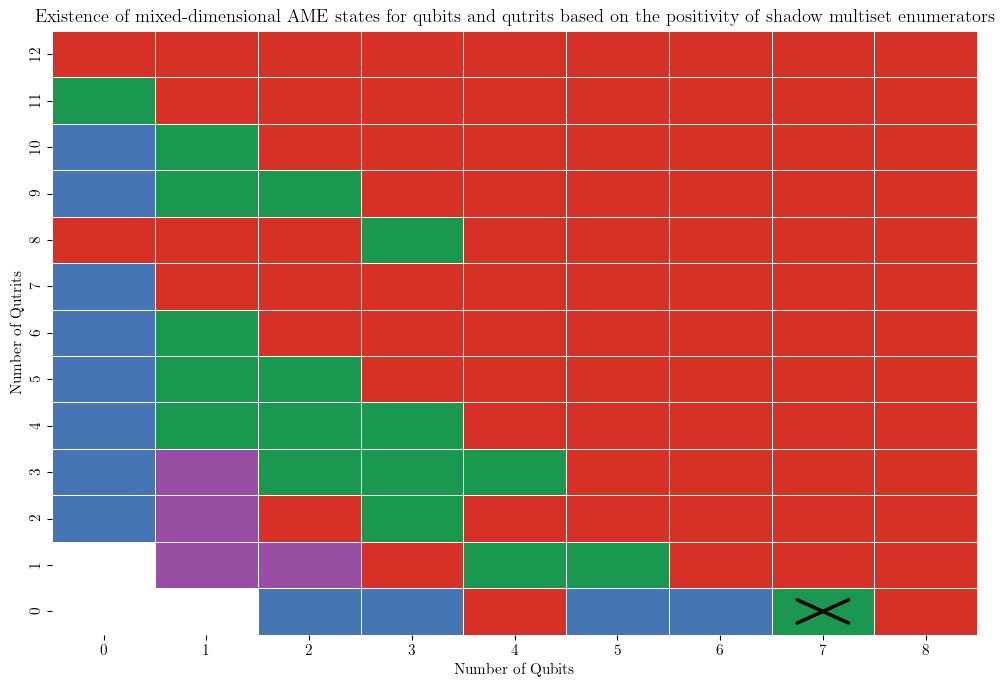

In [44]:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11, 
})

min_val = 0
max_qubits = 8
max_qutrits = 12

results = np.zeros((max_qutrits - min_val + 1, max_qubits - min_val + 1))

# Lists of known existing homogeneous AME states
known_qubits = [2, 3, 5, 6]
known_qutrits = [2, 3, 4, 5, 6, 7, 9, 10]

# List of known existing heterogeneous AME states mapped as (n_qubits, n_qutrits)
known_heterogeneous = [(1, 3), (2, 1), (1, 2), (1,1)]

for i, n3 in enumerate(range(min_val, max_qutrits + 1)):
    for j, n2 in enumerate(range(min_val, max_qubits + 1)):
        
        # PHYSICAL CONSTRAINT LOGIC 
        # No entanglement possible for < 2 parties
        if n2 + n3 < 2:
            results[i, j] = 3  # Map 3 to White
            continue # Skip the computation for these cells
            
        dims = [2] * n2 + [3] * n3
        
        system = MixedDimensionalErrorBasis(dims) 
        
        ame_shadows = system.AME_Shadow()
        
        is_feasible = 1
        for val in ame_shadows.values():
            if np.real(val) < -1e-10:
                is_feasible = 0
                break
        
        # HIGHLIGHTING LOGIC 
        is_known_homo = False
        is_known_hetero = False
        
        # Check Homogeneous
        if n3 == 0 and n2 in known_qubits:       
            is_known_homo = True
        elif n2 == 0 and n3 in known_qutrits:    
            is_known_homo = True
            
        # Check Heterogeneous
        if (n2, n3) in known_heterogeneous:
            is_known_hetero = True
            
        # Assign values based on priority
        if is_known_homo:
            results[i, j] = 2  # Assign 2 (Blue) for known homogeneous
        elif is_known_hetero:
            results[i, j] = 4  # Assign 4 (Purple) for known heterogeneous
        else:
            results[i, j] = is_feasible  # Assign 0 (Red) or 1 (Green)


plt.figure(figsize=(10, 7))

# Define a custom discrete colormap: 
# 0 -> Red (Infeasible), 1 -> Green (Feasible shadows)
# 2 -> Blue (Known Homogeneous), 3 -> White (No entanglement possible)
# 4 -> Purple (Known Heterogeneous)
cmap_custom = ListedColormap(['#d73027', '#1a9850', '#4575b4', '#ffffff', '#984ea3'])

# Plot without internal numbers (annot=False)
# vmin=0 and vmax=4 ensure the 5 numbers map perfectly to the 5 colors
ax = sns.heatmap(results, annot=False, cmap=cmap_custom, cbar=False, 
                vmin=0, vmax=4,
                linewidths=0.5, linecolor='white', 
                xticklabels=range(min_val, max_qubits + 1), 
                yticklabels=range(min_val, max_qutrits + 1))

# Historical cross for the AME(7,2) state
x_cross, y_cross = 7.5, 0.5
d = 0.25 # This controls the size of the cross arms

# Draw the two lines forming the cross
ax.plot([x_cross - d, x_cross + d], [y_cross - d, y_cross + d], 
        color='black', lw=2.5, solid_capstyle='round')
ax.plot([x_cross - d, x_cross + d], [y_cross + d, y_cross - d], 
        color='black', lw=2.5, solid_capstyle='round')

plt.title("Existence of mixed-dimensional AME states for qubits and qutrits based on the positivity of shadow multiset enumerators")
plt.xlabel("Number of Qubits")
plt.ylabel("Number of Qutrits")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Ame_shadows_qubits_qutrits.pdf")
plt.show()

We can generalize this to any $d_1,d_2$ dimensions.

In [45]:
# Tell Matplotlib to use LaTeX for all text rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 11,
})

def plot_mixed_ame_heatmap(d1, d2, max_n1, max_n2, 
                           known_homo_d1=None, known_homo_d2=None, 
                           known_hetero=None, min_val=0):
    """
    Generates a heatmap for the existence of mixed-dimensional AME states.
    
    Parameters:
    - d1, d2: The local dimensions of the two systems (e.g., 3 and 4).
    - max_n1, max_n2: Maximum number of subsystems for d1 and d2 respectively.
    - known_homo_d1: List of lengths for known homogeneous AME states of dimension d1.
    - known_homo_d2: List of lengths for known homogeneous AME states of dimension d2.
    - known_hetero: List of tuples (n1, n2) for known heterogeneous AME states.
    - min_val: Minimum number of subsystems to plot (usually 0).
    """
    
    # Handle mutable defaults
    known_homo_d1 = known_homo_d1 or []
    known_homo_d2 = known_homo_d2 or []
    known_hetero = known_hetero or []

    # Initialize results grid
    results = np.zeros((max_n2 - min_val + 1, max_n1 - min_val + 1))

    for i, n2 in enumerate(range(min_val, max_n2 + 1)):
        for j, n1 in enumerate(range(min_val, max_n1 + 1)):
            
            # No entanglement possible for < 2 parties
            if n1 + n2 < 2:
                results[i, j] = 3  # Map 3 to White
                continue
                
            dims = [d1] * n1 + [d2] * n2
            
            system = MixedDimensionalErrorBasis(dims) 
            ame_shadows = system.AME_Shadow()
            
            is_feasible = 1
            for val in ame_shadows.values():
                if np.real(val) < -1e-10:
                    is_feasible = 0
                    break
            
            #  HIGHLIGHTING LOGIC 
            is_known_homo = False
            
            # Check Homogeneous
            if n2 == 0 and n1 in known_homo_d1:       
                is_known_homo = True
            elif n1 == 0 and n2 in known_homo_d2:    
                is_known_homo = True
                
            # Check Heterogeneous
            is_known_hetero = (n1, n2) in known_hetero
                
            # Assign values based on priority
            if is_known_homo:
                results[i, j] = 2  # Assign 2 (Blue) for known homogeneous
            elif is_known_hetero:
                results[i, j] = 4  # Assign 4 (Purple) for known heterogeneous
            else:
                results[i, j] = is_feasible  # Assign 0 (Red) or 1 (Green)

    plt.figure(figsize=(10, 7))

    # Define a custom discrete colormap
    # 0: Red (Infeasible), 1: Green (Feasible), 2: Blue (Known Homo), 3: White (N/A), 4: Purple (Known Hetero)
    cmap_colors = ['#d73027', '#1a9850', '#4575b4', '#ffffff', '#984ea3']
    cmap_custom = ListedColormap(cmap_colors)

    ax = sns.heatmap(results, annot=False, cmap=cmap_custom, cbar=False, 
                    vmin=0, vmax=4,
                    linewidths=0.5, linecolor='white', 
                    xticklabels=range(min_val, max_n1 + 1), 
                    yticklabels=range(min_val, max_n2 + 1))

    plt.title(f"Existence of mixed-dimensional AME states ($d={d1}$ and $d={d2}$)\nbased on the positivity of shadow multiset enumerators")
    plt.xlabel(f"Number of subsystems ($d={d1}$)")
    plt.ylabel(f"Number of subsystems ($d={d2}$)")
    plt.gca().invert_yaxis()
    
    
    legend_patches = [
        mpatches.Patch(color='#d73027', label='Forbidden (Negative Shadow)'),
        mpatches.Patch(color='#1a9850', label='Potentially Feasible'),
        mpatches.Patch(color='#4575b4', label='Known Homogeneous AME'),
        mpatches.Patch(color='#984ea3', label='Known Heterogeneous AME'),
        mpatches.Patch(color='#ffffff', label='N/A (< 2 parties)', ec='black', lw=0.5)
    ]
    #plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) I personally do not use the legend.

    plt.tight_layout()
    plt.show()

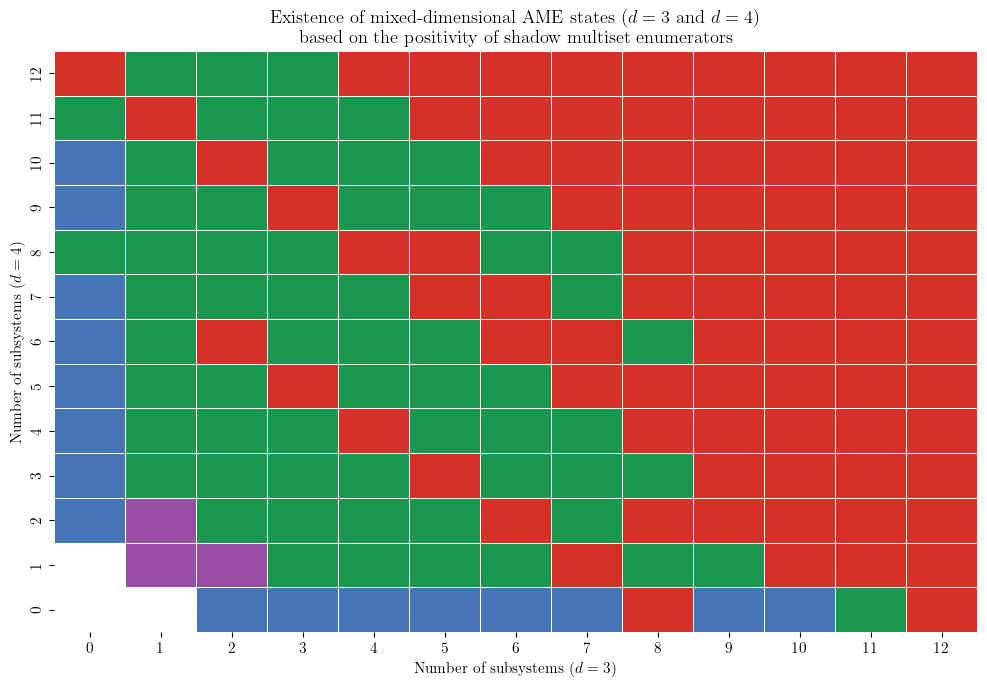

In [46]:
plot_mixed_ame_heatmap(
    d1=3, 
    d2=4, 
    max_n1=12,  # max qutrits
    max_n2=12,  # max ququarts
    known_homo_d1=[2,3,4,5,6,7,9,10], # Known qutrit AME lengths
    known_homo_d2=[2,3,4,5,6,7,9,10], # Known ququart AME lengths
    known_hetero=[(2,1),(1,2),(1,1)]  # Add known mixed tuples if you have them, e.g., [(1, 3)]
)

# Tripartite AME states

In [47]:
dims = [3,3,4]
system=MixedDimensionalErrorBasis(dims)
generated_dict = TripartiteAMEGrid(d1=dims[0], d2=dims[1], d3=dims[2]) # The solution might differ from the one in the preprint because it is not unique necessarily and does not yield minimal support AMEs
system.AME_Check(generated_dict) #We want to check the enumerators but also the maximally mixed states (in this case just the single party ones. The enumerators would be enough).

Searching for AME grid: d1=3, d2=3, d3=4
Solution Found!

=== Grid ===
   7/48|0> |     1/6|3> |    1/48|1>
    1/6|1> |    5/48|0> |    1/16|3>
   1/48|3> |    1/16|1> |     1/4|2>
System dimensions: [3, 3, 4]
Subspace dimension (Rank of P): 1.0

Multiset v      | A_v (def)    | B_v (def)    | S_v (def)    
---------------------------------------------------------------------------
()              | 1.0000       | 1.0000       | 0.0000       
(3,)            | 0.0000       | 0.0000       | 3.0000       
(4,)            | 0.0000       | 0.0000       | 1.1667       
(3, 3)          | 1.2500       | 1.2500       | -0.0000      
(3, 4)          | 6.0000       | 6.0000       | 0.0000       
(3, 3, 4)       | 27.7500      | 27.7500      | 3.8333       

Checking partial traces...
Reduction to subsystem 3 (Index 0):
[[0.3333+0.j 0.    +0.j 0.    +0.j]
 [0.    +0.j 0.3333+0.j 0.    +0.j]
 [0.    +0.j 0.    +0.j 0.3333+0.j]]
------------------------------
Reduction to subsystem 3 (Index 1):
[[